# Underfitting Model

by Niklas Vogel and Kevin Stupar

## Setup
This notebook creates an underfitting model and evaluates it.

Before executing this please make sure you did download and extract the data using an unzip tool optimized for your OS (`unzip` in WSL could take a long time)
The Download can be done using `setup.sh`

## Data Credit
TODO

# Load the data and split it

In [8]:
from helper import get_data, plot_accuracy_and_loss, plot_confusion_matrix, plot_samples, plot_number_per_class, calculate_predictions, plot_scores
from keras import layers, models

image_size = (64, 64)
batch_size = 32

(all_images, train_images, validation_images, test_images, label_names) = get_data(image_size)

Number of training images:  5683
Number of validation images:  1420
Number of testing images:  3045
Class names:  ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


# Inspecting the data

Before we train the model we want to know how the data looks like so we know what we are dealing with.

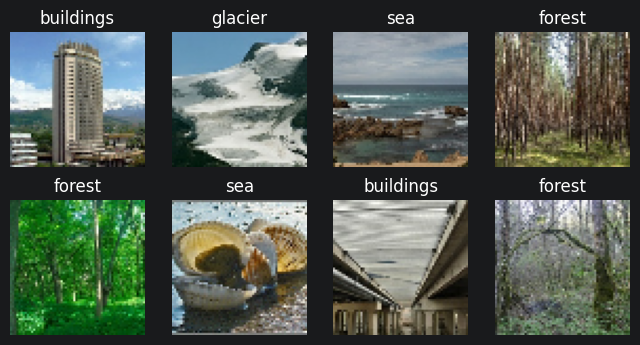

In [9]:
plot_samples(all_images, label_names)

Here we can see that all classes have exactly 4000 images, except for Karacadag, which only has 150 images.
This should lead to a worse performance of this class.

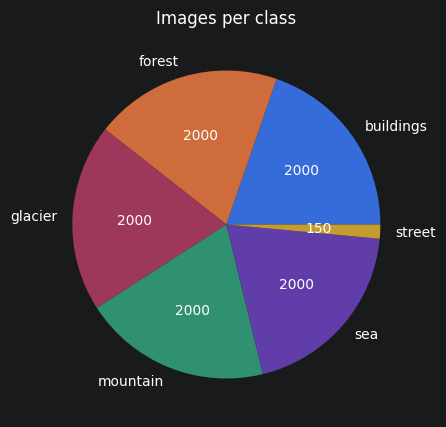

In [10]:
plot_number_per_class("Images per Class (all)", all_images, label_names)
plot_number_per_class("Images per Class (train)", train_images, label_names)
plot_number_per_class("Images per Class (validation)", validation_images, label_names)
plot_number_per_class("Images per Class (test)", test_images, label_names)

In [11]:
model = models.Sequential([
    layers.Input(shape=image_size +(3,)),
    layers.Rescaling(1./255),
    layers.Conv2D(16, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(8, (3,3), activation="relu"),
    layers.MaxPooling2D((8,8)),
    layers.Flatten(),
    layers.Dense(len(label_names), activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 29, 29, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 72)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           438 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,046 (7.99 KB)

 Trainable params: 2,046 (7.99 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(train_images.batch(batch_size), epochs=30, validation_data=validation_images.batch(batch_size))

Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4374 - loss: 1.3974 - val_accuracy: 0.5190 - val_loss: 1.1501
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5731 - loss: 1.0932 - val_accuracy: 0.5697 - val_loss: 1.0642
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6125 - loss: 1.0025 - val_accuracy: 0.6479 - val_loss: 0.9498
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6632 - loss: 0.9195 - val_accuracy: 0.6789 - val_loss: 0.8637
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6826 - loss: 0.8684 - val_accuracy: 0.6944 - val_loss: 0.8514
Epoch 6/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6991 - loss: 0.8372 - val_accuracy: 0.7282 - val_loss: 0.7918
Epoch 7/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7086 - loss: 0.8075 - val_accuracy: 0.6930 - val_loss: 0.8092
Epoch 8/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7192 - loss: 0.7796 - val_accuracy: 0.

# Evaluating the model

Using a few plots we can see, that the model is underfitting.
Note that the loss is on a log scale to be able to interpret the results better.

In [13]:
true, pred = calculate_predictions(model, test_images.batch(batch_size))

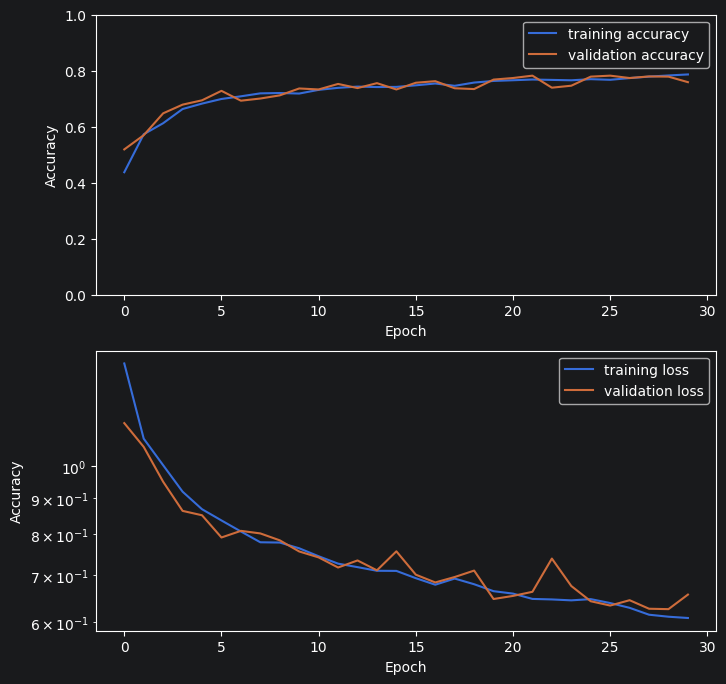

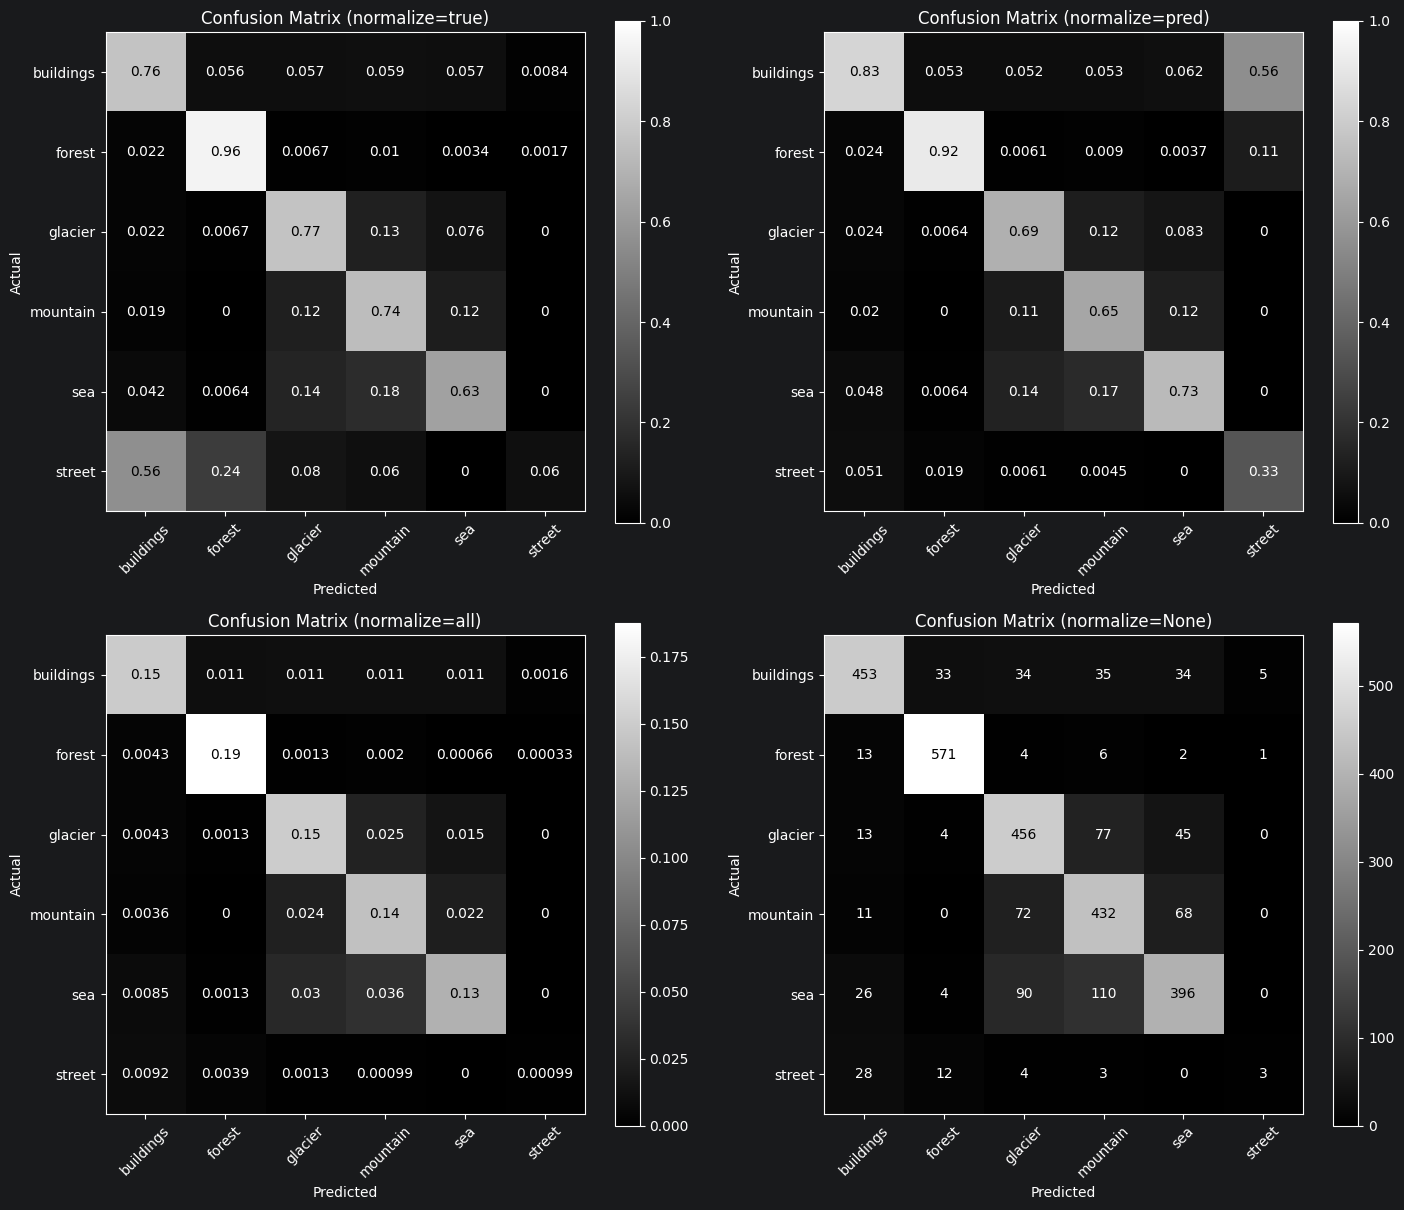

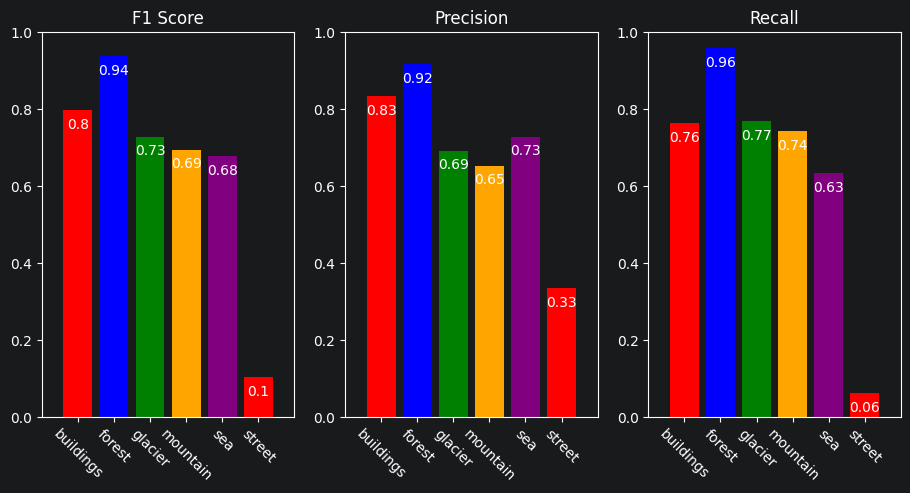

In [14]:
plot_accuracy_and_loss(history.history["accuracy"], history.history["val_accuracy"], history.history["loss"], history.history["val_loss"])

plot_confusion_matrix(true, pred, label_names)
plot_scores(true, pred, label_names)

# Discussion

The model has an accuracy of 0.97 which is very high considering it has only 551 trainable parameters. This is probably due to the amount of very good images with nearly no noise.
This theorie gets backed up when we look at the training metrics. The classes with 2k images have nearly perfect scores. But the metrics of the class (Karacadag) with only 150 images are much worse.
Karacadag having a bad F1 score just tells us that the dataset is unbalanced so thats not further surprising.
Karacadag having a not to bad precision is a bit surprising but explained when we look at the bad recall of Karacadag. The racall tells us that only in 44% of Karacadag even get classified as such. This shows the underfitting of the model with having high bias towards the other classes. And this also explains the high precision as the model only predicts Karacadag in very confidant cases.
The same can be see quite nicely in the first confusion matrix. Most Karacadag get calssified as ....

